### **Testando Augmentation**

In [1]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import numpy as np
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
from src.utils import get_corners_from_angle

import math
from PIL import Image, ImageDraw

In [2]:
def generate_roi_from_points(points, img_height, img_width):
    """
    Gera bounding box (ROI) com base em dois pontos.
    A ROI terá:
        - largura = distância entre os pontos
        - altura  = 2x distância entre os pontos
    E conterá os dois pontos.
    
    Retorna: (x_min, y_min, x_max, y_max)
    """
    x1, y1 = points[0]
    x2, y2 = points[1]

    # Distância euclidiana entre os pontos
    dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    # Centro da bounding box: ponto médio entre p1 e p2
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    # Metade das dimensões da ROI
    half_w = dist 
    half_h = dist # altura = 2 * dist → metade é dist

    # Coordenadas da ROI
    x_min = int(cx - half_w)
    x_max = int(cx + half_w)
    y_min = int(cy - half_h)
    y_max = int(cy + half_h)

    # Garantir que está dentro da imagem
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(img_width - 1, x_max)
    y_max = min(img_height - 1, y_max)

    roi_mask = Image.new("L", (img_width, img_height), 0)  # fundo preto
    draw = ImageDraw.Draw(roi_mask)
    draw.rectangle([x_min, y_min, x_max, y_max], fill=255)  # ROI branca

    return roi_mask

In [3]:
def load_points(path: str, filename: str = 'Results.csv') -> np.ndarray:
        """Carrega e converte os pontos do arquivo CSV."""
        full_path = path
        if not os.path.exists(full_path):
            raise FileNotFoundError(f"Arquivo de pontos não encontrado: {full_path}")

        df = pd.read_csv(full_path)
        if df.empty:
            raise ValueError(f"Arquivo de pontos vazio: {full_path}")

        row = df.iloc[0]
        return get_corners_from_angle(
            row['BX'], row['BY'], row['Width'], row['Height'], row['Angle']
        )

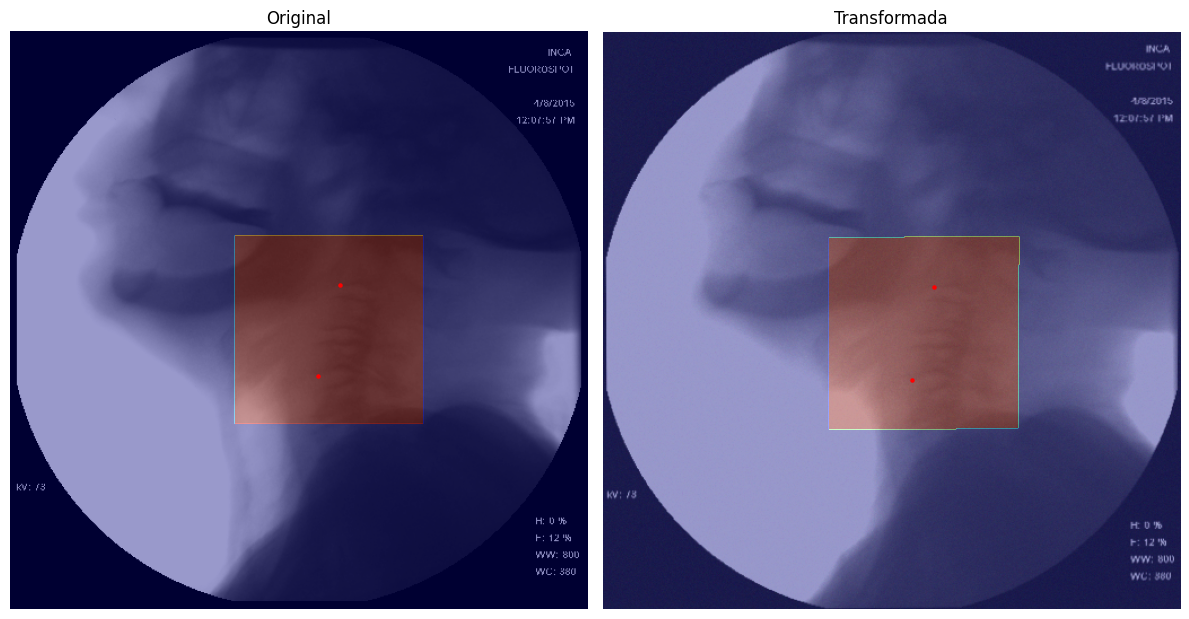

In [68]:
transform = A.Compose([
    A.Resize(512, 512),

    A.PixelDropout(dropout_prob = 0.01, p = 0.5),
    A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
    A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
    A.CropAndPad(px=(-30, 30), p=0.5),
    A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
    
    A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
    A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano

    ToTensorV2()
],
keypoint_params=A.KeypointParams(format='xy', label_fields=['keypoint_labels']),
)

# Read an image with OpenCV and convert it to the RGB colorspace
image = cv2.imread(r"C:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\data\frames\v1_f82.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

keypoints = load_points(r"C:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\data\rotulos\anotacoes-tecgraf\batch-2\VC\v1_f82\Results.csv")
keypoint_labels = [0, 1]

mask = np.array(generate_roi_from_points(keypoints, image.shape[0], image.shape[1]))
mask_labels = [0]

# Augment an image
transformed = transform(image=image,
                        mask=mask,
                        mask_labels=mask_labels,
                        keypoints=keypoints,
                        keypoint_labels=keypoint_labels)

transformed_image = transformed["image"]
transformed_image = transformed_image.permute(1,2,0)

transformed_keypoint = np.array(transformed["keypoints"])
transformed_keypoint_labels = transformed["keypoint_labels"]

transformed_mask = transformed['mask']
transformed_mask_labels = transformed['mask_labels']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))

ax[0].imshow(image)
ax[0].imshow(mask, cmap="jet", alpha=0.4)   # máscara
ax[0].scatter(keypoints[:,0], keypoints[:,1], c="r", s=5)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(transformed_image)
ax[1].imshow(transformed_mask, cmap="jet", alpha=0.4)   # máscara
ax[1].scatter(transformed_keypoint[:,0], transformed_keypoint[:,1], c="r", s=5)
ax[1].set_title("Transformada")
ax[1].axis("off")

plt.tight_layout()
plt.show()